<a href="https://colab.research.google.com/github/satani99/triton_kernels/blob/main/intro_to_triton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from IPython.core.debugger import set_trace

os.environ['TRITON_INTERPRET'] = '1'

def check_tensors_gpu_ready(*tensors):
  for t in tensors:
    assert t.is_contiguous, "A tensor is not contiguous"
    if not os.environ.get('TRITON_INTERPRET') == '1': assert t.is_cuda, "A tensor is not on cuda"

def test_pid_conds(conds, pid_0=[0], pid_1=[0], pid_2=[0]):
  '''Test if condition on pids are fulfilled
  E.g.:
    '=0' checks that pid_0 == 0
    '>1' checks that pid_1 > 1
    '>1,=0' checks that pid_0 > 1 and pid_1 == 0
  '''
  pids = pid_0[0], pid_1[0], pid_2[0]
  conds = conds.replace(' ', '').split(',')
  for i, (cond, pid) in enumerate(zip(conds, pids)):
    if cond=='': continue
    op, threshold = cond[0], int(cond[1:])
    if op not in ['<', '>', '>=', '<=', '=', '!=']: raise ValueError(f"Rules may only use these ops: '<', '>', '>=', '<=', '=', '!='. Invalid rule: '{condition}'.")
    op = '==' if op == '=' else op
    if not eval(f'{pid} {op} {threshold}'): return False
  return True

assert test_pid_conds('')
assert test_pid_conds('>0', [1], [1])
assert not test_pid_conds('>0', [0], [1])
assert test_pid_conds('=0,=1', [0], [1], [0])

def breakpoint_if(conds, pid_0=[0], pid_1=[0], pid_2=[0]):
  '''Stop kernel, if any condition of pids is fulfilled'''
  if test_pid_conds(conds, pid_0, pid_1, pid_2): set_trace()

def print_if(txt, conds, pid_0=[0], pid_1=[0], pid_2=[0]):
  '''Print txt, if any condition of pids is fulfilled'''
  if test_pid_conds(conds, pid_0, pid_1, pid_2): print(txt)

def cdiv(a, b): return (a + b - 1) // b
assert cdiv(10, 2) == 5
assert cdiv(10, 3) == 4

In [ ]:
import torch
import triton
import triton.language as tl

# Copying a tensor

In [ ]:
def copy(x, bs, kernel_fn):
  z = torch.zeros_like(x)
  check_tensors_gpu_ready(x, z)
  n = x.numel()
  n_blocks = cdiv(n, bs)
  grid = (n_blocks, )

  kernel_fn[grid](x, z, n, bs)

  return z

In [ ]:
@triton.jit
def copy_k(x_ptr, z_ptr, n, bs: tl.constexpr):
  pid = tl.program_id(0)
  offs = pid * bs + tl.arange(0, bs)
  mask = offs < n
  x = tl.load(x_ptr + offs, mask)
  tl.store(z_ptr + offs, x, mask)
  print_if(f'pid = {pid} | offs = {offs}, mask = {mask}, x = {x}', '')


In [ ]:
z = copy(x, bs=2, kernel_fn=copy_k)

pid = [0] | offs = [0 1], mask = [ True  True], x = [1 2]
pid = [1] | offs = [2 3], mask = [ True  True], x = [3 4]
pid = [2] | offs = [4 5], mask = [ True  True], x = [5 6]


In [ ]:
x, z

(tensor([1, 2, 3, 4, 5, 6]), tensor([1, 2, 3, 4, 5, 6]))

In [ ]:
!uv pip install triton

Using Python 3.12.13 environment at: /usr
Checked 1 package in 174ms


In [ ]:
!uv pip install torch torchvision torchaudio


Using Python 3.12.13 environment at: /usr
Checked 3 packages in 109ms


# Greyscaling an image

In [ ]:
import os

import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from pathlib import Path

import torch
from torch import tensor
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io

import triton
import triton.language as tl

In [ ]:
def cdiv(a, b): return (a + b - 1) // b

In [ ]:
path_img = Path('puppy.jpg')
url = 'https://upload.wikimedia.org/wikipedia/commons/4/43/Cute_dog.jpg'
if not path_img.exists():
  import urllib.request
  # Create an opener to add a User-Agent header
  # This can help bypass HTTP 403 Forbidden errors from servers that block requests without a proper User-Agent
  opener = urllib.request.build_opener()
  opener.addheaders = [('User-agent', 'Mozilla/5.0')]
  urllib.request.install_opener(opener)
  urllib.request.urlretrieve(url, path_img)

In [ ]:
img = io.read_image('puppy.jpg')
print(img.shape)
img[:2, :3, :4]

torch.Size([3, 2117, 3176])


tensor([[[118, 118, 120, 119],
         [118, 125, 119, 117],
         [112, 120, 120, 125]],

        [[ 79,  81,  82,  83],
         [ 81,  90,  83,  82],
         [ 72,  84,  86,  91]]], dtype=torch.uint8)

In [ ]:

def show_img(x, figsize=(4,3), **kwargs):
  plt.figure(figsize=figsize)
  plt.axis('off')
  if len(x.shape)==3: x = x.permute(1, 2, 0)
  plt.imshow(x.cpu(), **kwargs)

In [ ]:
img = tvf.resize(img, 150, antialias=True)
ch, h, w = img.shape
ch, h, w, h*w

(3, 150, 225, 33750)

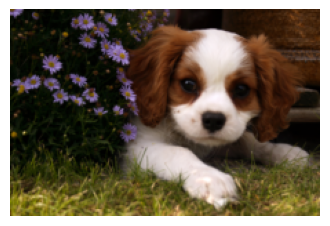

In [ ]:
show_img(img)

In [ ]:
@triton.jit
def rgb2grey_k(x_ptr, out_ptr, h, w, bs0: tl.constexpr, bs1: tl.constexpr):
  pid_0 = tl.program_id(0)
  pid_1 = tl.program_id(1)

  offs_0 = pid_0 * bs0 + tl.arange(0, bs0)
  offs_1 = pid_1 * bs1 + tl.arange(0, bs1)

  offs = w * offs_0[:, None] + offs_1[None, :]

  mask_0 = offs_0 < h
  mask_1 = offs_1 < w

  mask = mask_0[:, None] & mask_1[None, :]

  r = tl.load(x_ptr + 0*h*w + offs, mask=mask)
  g = tl.load(x_ptr + 1*h*w + offs, mask=mask)
  b = tl.load(x_ptr + 2*h*w + offs, mask=mask)

  out = 0.2989*r + 0.5870*g + 0.1140*b

  tl.store(out_ptr + offs, out, mask=mask)


In [ ]:
def rgb2grey(x, bs):
  c, h, w = x.shape
  out = torch.empty((h, w), dtype=x.dtype, device=x.device)

  grid = lambda meta: (cdiv(h, meta['bs0']), cdiv(w, meta['bs1']))
  # print(meta['bs0'])
  # print(meta['bs1'])

  rgb2grey_k[grid](x, out, h, w, bs0=bs[0], bs1=bs[1])
  return out.view(h, w)

In [ ]:
grey_img = rgb2grey(img.to('cuda'), bs=(32, 32)).to('cpu')

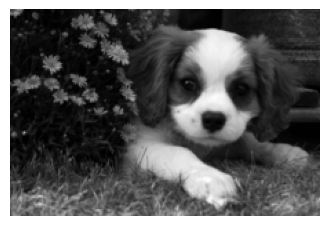

In [ ]:
show_img(grey_img, cmap='gray')

In [ ]:
!uv pip install triton

Using Python 3.12.13 environment at: /usr
Checked 1 package in 220ms


# Matmul

In [ ]:
import os
import torch
import triton
import triton.language as tl

In [ ]:
@triton.jit
def get_1d_offset(size, n_prev_chunks):
  return n_prev_chunks * size + tl.arange(0, size)

@triton.jit
def get_2d_offset(offs_0, offs_1, stride_0, stride_1=1):
  return tl.expand_dims(offs_0, 1) * stride_0 + tl.expand_dims(offs_1, 0) * stride_1

@triton.jit
def get_1d_mask(offs, max):
  return offs < max

@triton.jit
def get_2d_mask(offs_0, offs_1, max_0, max_1):
  return (tl.expand_dims(offs_0, 1) < max_0) & (tl.expand_dims(offs_1, 0) < max_1)

In [ ]:
@triton.jit
def naive_matmul_k(
    a_ptr, b_ptr, c_ptr,
    m, n, k,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    bm: tl.constexpr, bn: tl.constexpr, bk: tl.constexpr
):
    pid_m, pid_n = tl.program_id(0), tl.program_id(1)

    rm = get_1d_offset(size=bm, n_prev_chunks=pid_m)
    rn = get_1d_offset(size=bn, n_prev_chunks=pid_n)
    rk = get_1d_offset(size=bk, n_prev_chunks=0)

    offs_a = a_ptr + get_2d_offset(rm, rk, stride_am, stride_ak)
    offs_b = b_ptr + get_2d_offset(rk, rn, stride_bk, stride_bn)

    mask_a = get_2d_mask(rm, rk, m, k)
    mask_b = get_2d_mask(rk, rn, k, n)

    acc = tl.zeros((bm, bn), dtype=tl.float32)
    for _ in range(0, k, bk):
      a = tl.load(offs_a, mask=mask_a)
      b = tl.load(offs_b, mask=mask_b)
      acc += tl.dot(a, b, allow_tf32=False)

      offs_a += bk * stride_ak
      offs_b += bk * stride_bk

    c = c_ptr + get_2d_offset(rm, rn, stride_cm, stride_cn)
    mask = get_2d_mask(rm, rn, m, n)
    tl.store(c, acc, mask=mask)

In [ ]:
from functools import partial

def matmul(a, b, matmul_k_fun, bs=16, group_sz=None):
  assert a.shape[1] == b.shape[0]
  check_tensors_gpu_ready(a, b)
  (m, k), (_, n) = a.shape, b.shape
  c = torch.empty((m, n), device=a.device, dtype=torch.float16)
  grid = lambda meta: (triton.cdiv(m, meta['bm']), triton.cdiv(n, meta['bn']))
  group_sz = {} if group_sz is None else {"group_sz": group_sz}
  matmul_k_fun[grid](
      a, b, c,
      m, n, k,
      a.stride(0), a.stride(1),
      b.stride(0), b.stride(1),
      c.stride(0), c.stride(1),
      bm=bs, bn=bs, bk=bs,
      **group_sz
  )
  return c

naive_matmul = partial(matmul, matmul_k_fun=naive_matmul_k)

In [ ]:
a = torch.rand((3, 1000), dtype=torch.float32, device='cuda')
b = torch.rand((1000, 5), dtype=torch.float32, device='cuda')

In [ ]:
naive_matmul(a, b)

/usr/local/lib/python3.12/dist-packages/triton/runtime/interpreter.py:469: RuntimeWarning: overflow encountered in cast
  return TensorHandle(src.data.astype(_get_np_dtype(dst_type)), dst_type.scalar)


tensor([[240.6250, 250.0000,     -inf, 252.0000, 256.2500],
        [235.8750, 235.7500,     -inf, 244.0000, 252.0000],
        [239.3750,     -inf, 241.8750,     -inf, 248.7500]], device='cuda:0',
       dtype=torch.float16)

In [ ]:
torch.manual_seed(0)
a = torch.randn((512, 512), device='cuda', dtype=torch.float16)
b = torch.randn((512, 512), device='cuda', dtype=torch.float16)
triton_output = naive_matmul(a, b)
torch_output = torch.matmul(a, b)
if torch.allclose(triton_output, torch_output, atol=5e-2, rtol=0):
  print("Triton and Torch match")
else:
  print("Triton and Torch differ")


Triton and Torch match


# Faster Matmul

In [ ]:
def process_item(id): print(f"I'm processing itme {id}")

for i in range(5):process_item(i)

I'm processing itme 0
I'm processing itme 1
I'm processing itme 2
I'm processing itme 3
I'm processing itme 4


In [ ]:
def change_id(old_id): return 5 - old_id

for i in range(5): process_item(change_id(i))

I'm processing itme 5
I'm processing itme 4
I'm processing itme 3
I'm processing itme 2
I'm processing itme 1


In [ ]:
@triton.jit
def swizzle_k(x_ptr, z_ptr, group_sz: tl.constexpr):
  pid_m, pid_n = tl.program_id(0), tl.program_id(1)
  num_pid_m, num_pid_n = tl.num_programs(0), tl.num_programs(1)

  pid_m_, pid_n_ = tl.swizzle2d(pid_m, pid_n, num_pid_m, num_pid_n, group_sz)

  offs_m = get_1d_offset(1, n_prev_chunks=pid_m)
  offs_n = get_1d_offset(1, n_prev_chunks=pid_n)

  offs = get_2d_offset(offs_m, offs_n, stride_0=num_pid_n)
  mask = get_2d_mask(offs_m, offs_n, max_0=num_pid_m, max_1=num_pid_n)

  offs_sw_m = get_1d_offset(1, n_prev_chunks=pid_m_)
  offs_sw_n = get_1d_offset(1, n_prev_chunks=pid_n_)

  offs_sw = get_2d_offset(offs_sw_m, offs_sw_n, stride_0=num_pid_n)
  mask_sw = get_2d_mask(offs_sw_m, offs_sw_n, max_0=num_pid_m, max_1=num_pid_n)

  x = tl.load(x_ptr + offs, mask=mask)
  tl.store(z_ptr + offs_sw, x, mask=mask_sw)

In [ ]:
blocks_m, blocks_n = 5, 4

x = torch.arange(blocks_m*blocks_n, device="cuda").view(blocks_m, blocks_n)
x

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]], device='cuda:0')

In [ ]:
z = -torch.ones_like(x)
z

tensor([[-1, -1, -1, -1],
        [-1, -1, -1, -1],
        [-1, -1, -1, -1],
        [-1, -1, -1, -1],
        [-1, -1, -1, -1]], device='cuda:0')

In [ ]:
swizzle_k[(blocks_m, blocks_n)](x, z, group_sz=3);

In [ ]:
z

tensor([[ 0,  3,  6,  9],
        [ 1,  4,  7, 10],
        [ 2,  5,  8, 11],
        [12, 14, 16, 18],
        [13, 15, 17, 19]], device='cuda:0')

In [ ]:
@triton.jit
def grouped_matmul_k(
    a_ptr, b_ptr, c_ptr,
    m, n, k,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    bm: tl.constexpr, bn: tl.constexpr, bk: tl.constexpr, group_sz: tl.constexpr
):
    pid_m, pid_n = tl.program_id(0), tl.program_id(1)
    num_pid_m, num_pid_n = tl.num_programs(0), tl.num_programs(1)

    pid_m, pid_n = tl.swizzle2d(pid_m, pid_n, num_pid_m, num_pid_n, group_sz)

    rm = get_1d_offset(size=bm, n_prev_chunks=pid_m)
    rn = get_1d_offset(size=bn, n_prev_chunks=pid_n)
    rk = get_1d_offset(size=bk, n_prev_chunks=0)

    offs_a = a_ptr + get_2d_offset(rm, rk, stride_am, stride_ak)
    offs_b = b_ptr + get_2d_offset(rk, rn, stride_bk, stride_bn)

    mask_a = get_2d_mask(rm, rk, m, k)
    mask_b = get_2d_mask(rk, rn, k, n)

    acc = tl.zeros((bm, bn), dtype=tl.float32)
    for _ in range(0, k, bk):
      a = tl.load(offs_a, mask=mask_a)
      b = tl.load(offs_b, mask=mask_b)
      acc += tl.dot(a, b, allow_tf32=False)

      offs_a += bk * stride_ak
      offs_b += bk * stride_bk

    c = c_ptr + get_2d_offset(rm, rn, stride_cm, stride_cn)
    mask = get_2d_mask(rm, rn, m, n)
    tl.store(c, acc, mask=mask)

In [ ]:
grouped_matmul = partial(matmul, matmul_k_fun=grouped_matmul_k)

In [ ]:
a = torch.ones((3, 4), dtype=torch.float32, device='cuda')
b = torch.ones((4, 5), dtype=torch.float32, device='cuda')

In [ ]:
grouped_matmul(a, b, group_sz=4)

tensor([[4., 4., 4., 4., 4.],
        [4., 4., 4., 4., 4.],
        [4., 4., 4., 4., 4.]], device='cuda:0', dtype=torch.float16)

In [ ]:
torch.manual_seed(0)
a = torch.randn((512, 512), device='cuda', dtype=torch.float16)
b = torch.randn((512, 512), device='cuda', dtype=torch.float16)
triton_output = grouped_matmul(a, b, group_sz=32)
torch_output = torch.matmul(a, b)
if torch.allclose(triton_output, torch_output, atol=5e-2, rtol=0):
  print("Triton and torch match")
else:
  print("triton and torch differ")

Triton and torch match


In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['square_matrix_size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(5, 12, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['naive', 'grouped', 'torch'],  # Possible values for `line_arg`.
        line_names=['Naive', 'Grouped', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-'), ('orange','-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='matmul-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(square_matrix_size, provider):
    sz = square_matrix_size
    a = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    b = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'naive':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: naive_matmul(a, b), quantiles=quantiles)
    if provider == 'grouped': ms, min_ms, max_ms = triton.testing.do_bench(lambda: grouped_matmul(a, b, group_sz=8), quantiles=quantiles)
    if provider == 'torch':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a,b), quantiles=quantiles)
    gbps = lambda ms: 12 * sz / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

In [ ]:
benchmark.run(print_data=True, show_plots=True)

KeyboardInterrupt: 

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['batch_size'], x_vals=[2**i for i in range(4, 7, 1)], x_log=True,
        line_arg='provider', line_vals=['naive', 'grouped', 'torch'], line_names=['Naive', 'Grouped', 'Torch'],
        styles=[('blue', '-'), ('green', '-'), ('orange','-')],
        ylabel='GB/s', plot_name='matmul-performance', args={}
    ))
def benchmark(batch_size, provider):
    sz = 512
    a = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    b = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'naive':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: naive_matmul(a, b, bs=batch_size), quantiles=quantiles)
    if provider == 'grouped': ms, min_ms, max_ms = triton.testing.do_bench(lambda: grouped_matmul(a, b, bs=batch_size, group_sz=8), quantiles=quantiles)
    if provider == 'torch':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a,b), quantiles=quantiles)
    gbps = lambda ms: 12 * sz / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

KeyboardInterrupt: 

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['square_matrix_size'], x_vals=[2**i for i in range(5, 12, 1)], x_log=True,
        line_arg='provider', line_vals=['naive', 'grouped', 'torch'], line_names=['Naive', 'Grouped', 'Torch'],
        styles=[('blue', '-'), ('green', '-'), ('orange','-')],
        ylabel='GB/s', plot_name='matmul-performance', args={}
    ))
def benchmark(square_matrix_size, provider):
    sz = square_matrix_size
    a = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    b = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'naive':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: naive_matmul(a, b, bs=64), quantiles=quantiles)
    if provider == 'grouped': ms, min_ms, max_ms = triton.testing.do_bench(lambda: grouped_matmul(a, b, group_sz=8, bs=64), quantiles=quantiles)
    if provider == 'torch':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a,b), quantiles=quantiles)
    gbps = lambda ms: 12 * sz / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

In [ ]:
@triton.autotune(
    # Choices of configs to auto-tune over
    configs=[
        triton.Config({'bm': 128, 'bn': 256, 'bk': 64, 'group_sz': 8}, num_stages=3, num_warps=8),
        triton.Config({'bm': 64, 'bn': 256, 'bk': 32, 'group_sz': 8}, num_stages=4, num_warps=4),
        triton.Config({'bm': 128, 'bn': 128, 'bk': 32, 'group_sz': 8}, num_stages=4, num_warps=4),
        triton.Config({'bm': 128, 'bn': 64, 'bk': 32, 'group_sz': 8}, num_stages=4, num_warps=4),
        triton.Config({'bm': 64, 'bn': 128, 'bk': 32, 'group_sz': 8}, num_stages=4, num_warps=4),
        triton.Config({'bm': 128, 'bn': 32, 'bk': 32, 'group_sz': 8}, num_stages=4, num_warps=4),
        triton.Config({'bm': 64, 'bn': 32, 'bk': 32, 'group_sz': 8}, num_stages=5, num_warps=2),
        triton.Config({'bm': 32, 'bn': 64, 'bk': 32, 'group_sz': 8}, num_stages=5, num_warps=2),
    ],
    # Definition of problem size. If it changes, a new auto-tune is run for the new problem size.
    key=['m', 'n', 'k'],
)
@triton.jit
def grouped_autotuned_matmul_k(
    a_ptr, b_ptr, c_ptr,
    m, n, k,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    bm: tl.constexpr, bn: tl.constexpr, bk: tl.constexpr, group_sz: tl.constexpr
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    num_pid_m = tl.num_programs(0)
    num_pid_n = tl.num_programs(1)
    # determine location of block in grouped ordering
    pid_m, pid_n = tl.swizzle2d(pid_m, pid_n, num_pid_m, num_pid_n, group_sz)  # Weirdness: tl.swizzle2d doesn't work when simulating on CPU
    # chunks along m/n/k dimensions
    rm = get_1d_offset(size=bm, n_prev_chunks=pid_m)
    rn = get_1d_offset(size=bn, n_prev_chunks=pid_n)
    rk = get_1d_offset(size=bk, n_prev_chunks=0)
    # relevant offsets of a, b
    offs_a = a_ptr + get_2d_offset(rm, rk, stride_am, stride_ak)
    offs_b = b_ptr + get_2d_offset(rk, rn, stride_bk, stride_bn)
    # initialize and iteratively update accumulator
    acc = tl.zeros((bm, bn), dtype=tl.float32)
    for _ in range(0, k, bk):
        # todo umer: don't we need mask when loading a & b?
        a = tl.load(offs_a)
        b = tl.load(offs_b)
        acc += tl.dot(a, b, allow_tf32=False) # block level matrix multiplication ; Weirdness: allow_tf32 must be set to False for older GPUs, otherwise won't compile
        # increase offets, so next iteration loads next chunks
        offs_a += bk * stride_ak
        offs_b += bk * stride_bk
    c = c_ptr + get_2d_offset(rm, rn, stride_cm, stride_cn)
    mask = get_2d_mask(rm, rn, m, n)
    tl.store(c, acc, mask=mask)

In [ ]:
def grouped_autotuned_matmul(a, b):
    matmul_k_fn = grouped_autotuned_matmul_k

    assert a.shape[1] == b.shape[0], "matrix dims not compatible for matmul"
    check_tensors_gpu_ready(a, b)
    (m, k), (_, n) = a.shape, b.shape
    c = torch.empty((m, n), device=a.device, dtype=torch.float16)
    grid = lambda meta: (triton.cdiv(m, meta['bm']),  triton.cdiv(n, meta['bn']))
    matmul_k_fn[grid](
        a, b, c,
        m, n, k,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        # bm=bs, bn=bs, bk=bs, <- will be autotuned
        # **group_sz <- will be autotuned
    )
    return c

In [ ]:
a,b = torch.ones(3,4, device='cuda'), torch.ones(4,5, device='cuda')

In [ ]:
a@b

In [ ]:
grouped_autotuned_matmul(a,b)

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['square_matrix_size'], x_vals=[2**i for i in range(5, 12, 1)], x_log=True,
        line_arg='provider', line_vals=['naive', 'grouped', 'grouped-autotuned', 'torch'], line_names=['Naive', 'Grouped', 'Grouped & Auto-Tuned','Torch'],
        styles=[('blue', '-'), ('green', '-'), ('green', '--'), ('orange','-')],
        ylabel='GB/s', plot_name='matmul-performance', args={}
    ))
def benchmark(square_matrix_size, provider):
    sz = square_matrix_size
    a = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    b = torch.rand((sz, sz), device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'naive':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: naive_matmul(a, b, bs=64), quantiles=quantiles)
    if provider == 'grouped': ms, min_ms, max_ms = triton.testing.do_bench(lambda: grouped_matmul(a, b, group_sz=8, bs=64), quantiles=quantiles)
    if provider == 'grouped-autotuned': ms, min_ms, max_ms = triton.testing.do_bench(lambda: grouped_autotuned_matmul(a, b), quantiles=quantiles)
    if provider == 'torch':   ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a,b), quantiles=quantiles)
    gbps = lambda ms: 12 * sz / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

# GeLU

In [2]:
!uv pip install triton

Using Python 3.12.13 environment at: /usr
Checked 1 package in 87ms


In [3]:
import torch
import triton
import triton.language as tl

In [4]:
k =(2.0 / torch.pi) ** 0.5

def gelu(x, bs):
  h, w = x.shape
  out = torch.empty((h, w), dtype=x.dtype, device=x.device)

  grid = lambda meta: (cdiv(h, meta['bs0']), cdiv(w, meta['bs1']))

  gelu_k[grid](x, out, h, w, bs0=bs[0], bs1=bs[1], k=k)
  return out.view(h, w)


In [5]:
@triton.jit
def gelu_k(x_ptr, out_ptr, h, w, bs0: tl.constexpr, bs1: tl.constexpr, k: tl.constexpr):
  pid_0 = tl.program_id(0)
  pid_1 = tl.program_id(1)

  offs_0 = pid_0 * bs0 + tl.arange(0, bs0)
  offs_1 = pid_1 * bs1 + tl.arange(0, bs1)

  offs = w * offs_0[:, None] + offs_1[None, :]

  mask_0 = offs_0 < h
  mask_1 = offs_1 < w

  mask = mask_0[:, None] & mask_1[None, :]

  x = tl.load(x_ptr + offs, mask=mask, other=0.0)

  t = (x + 0.044715 * x * x * x) * k
  numerator = 2
  denominator = (1 + tl.exp(-2 * t))
  gelu_output = 0.5 * x * (1 + (numerator / denominator) - 1)

  tl.store(out_ptr + offs, gelu_output, mask=mask)



In [6]:
torch.manual_seed(0)
x = torch.randn(4097, 311, device='cuda')
y_triton = gelu(x, bs=(512, 512))
y_torch = torch.nn.functional.gelu(x, approximate='tanh')
assert torch.allclose(y_triton, y_torch, rtol=1e-04,atol=1e-04), (y_triton, y_torch)

In [10]:
x = torch.randn(512, 4096, device="cuda")

y_triton = gelu(x, bs=(512, 512))
y_torch  = torch.nn.functional.gelu(x, approximate="tanh")

assert torch.allclose(y_triton, y_torch, rtol=1e-2, atol=1e-2), \
    f"max diff: {(y_triton - y_torch).abs().max()}"
print("✓ correctness check passed")

✓ correctness check passed


In [14]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["n_cols"],                        # x-axis variable
        x_vals=[256 * i for i in range(1, 50)],    # 256 → 16384
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton GELU", "PyTorch GELU"],
        styles=[("blue", "-"), ("gray", "--")],
        ylabel="GB/s",
        plot_name="GELU performance (FP16, 512 rows)",
        args={"n_rows": 512},
    )
)
def benchmark(n_rows, n_cols, provider):
    x = torch.randn(n_rows, n_cols, device="cuda")

    quantiles = [0.5, 0.2, 0.8]   # median, 20th, 80th percentile

    if provider == "triton":
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: gelu(x, bs=(512, 512)), quantiles=quantiles
        )
    elif provider == "torch":
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch.nn.functional.gelu(x, approximate="tanh"),
            quantiles=quantiles,
        )

    # throughput = bytes read + bytes written / time
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True)

KeyboardInterrupt: 

In [14]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=[
            'triton',
            'pytorch',
        ],  # possible values for `line_arg``
        line_names=[
            "Triton",
            "PyTorch",
        ],  # label name for the lines
        styles=[('blue', '-'), ('green', '-'), ('green', '--')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="gelu-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'pytorch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.nn.functional.gelu(x), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: gelu(x, bs=(512, 512)), quantiles=quantiles)
    gbps = lambda ms: 2 * x.nelement() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(show_plots=True, print_data=True)

KeyboardInterrupt: 